In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings
import matplotlib.colors as mcolors
import equinox as eqx
import jax

from pathlib import Path

from hypermagnetics import plots
from hypermagnetics.sources import read_db
from hypermagnetics.models.hyper_mlp import HyperLayer
from hypermagnetics.fmm_sources import potential2D
from hypermagnetics.sources import _potential, _total


warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])

In [6]:
data = read_db("val_eval_sphere_large_m_92_1000_1.h5")
# data_prism = read_db("val_res32_large_m_40_1000_1.h5")
import h5py
datapath = Path("/home/spol/repos/hypermagnetics/data")
db = h5py.File(datapath / "train_res32_large_m_42_200000_1_fno_64.h5", "r")
res = 64
lim = 1.2
idx = 15
print(f"Max size: {data['max_size']}")
print(f"Min size: {data['min_size']}")
# plots(data, loc=True, edge=True, number=True, idx=field_idx)

Max size: 0.47992128133773804
Min size: 0.0


In [7]:
print(db["input"].shape)
print(db["output"].shape)

(200000, 4096, 2)
(200000, 1024)


(1000, 4096, 2)


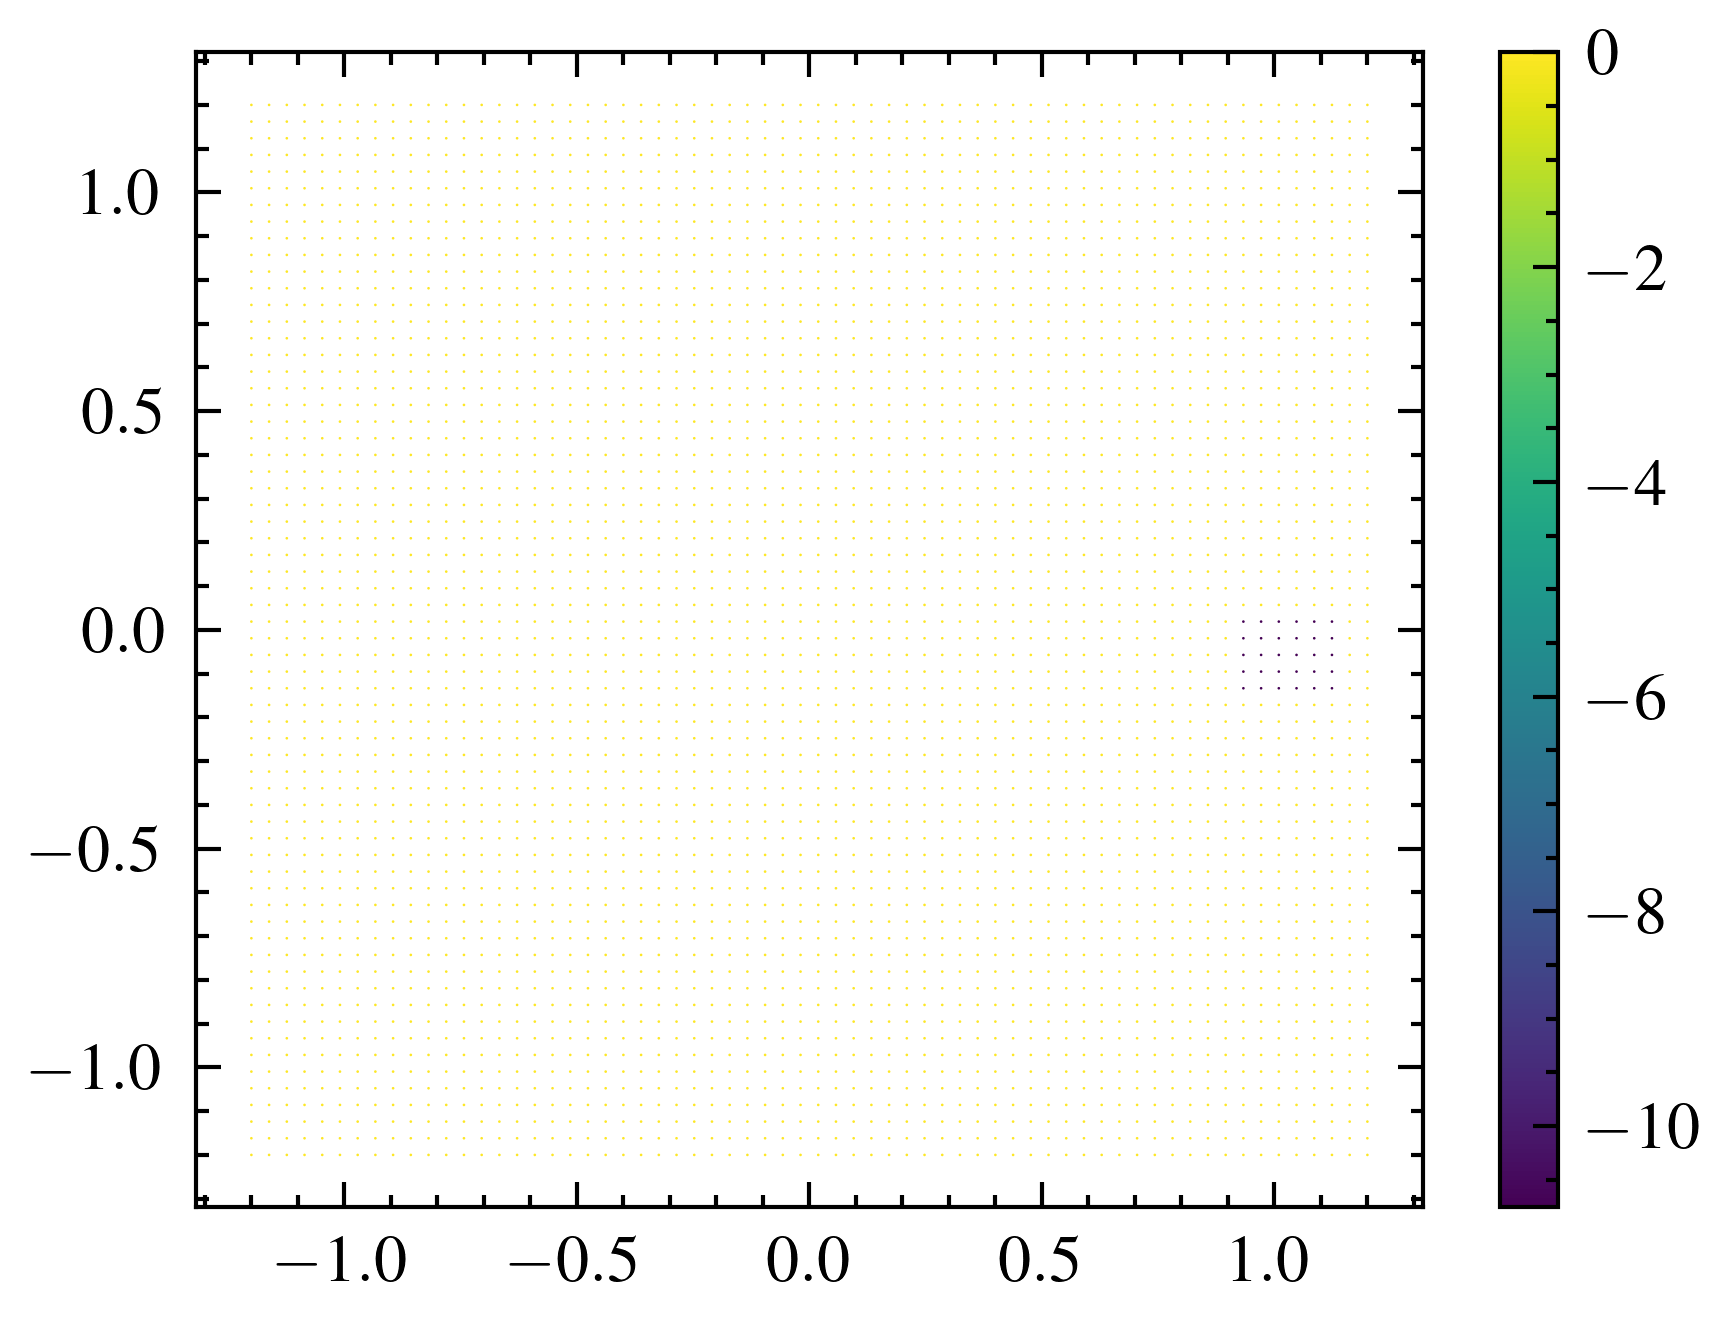

In [4]:
# Check fno function
print(db["input"].shape)

grids = np.meshgrid(
            np.linspace(-lim, lim, res),
            np.linspace(-lim, lim, res),
            np.linspace(0, 0, 1),
        )
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res)))
y_grid = np.array(grid[:, 1].reshape((res, res)))
contour = plt.scatter(x_grid, y_grid, c=db["input"][idx,...,0].reshape((res, res)), cmap='viridis', s=0.1, edgecolors='none')
plt.colorbar(contour)

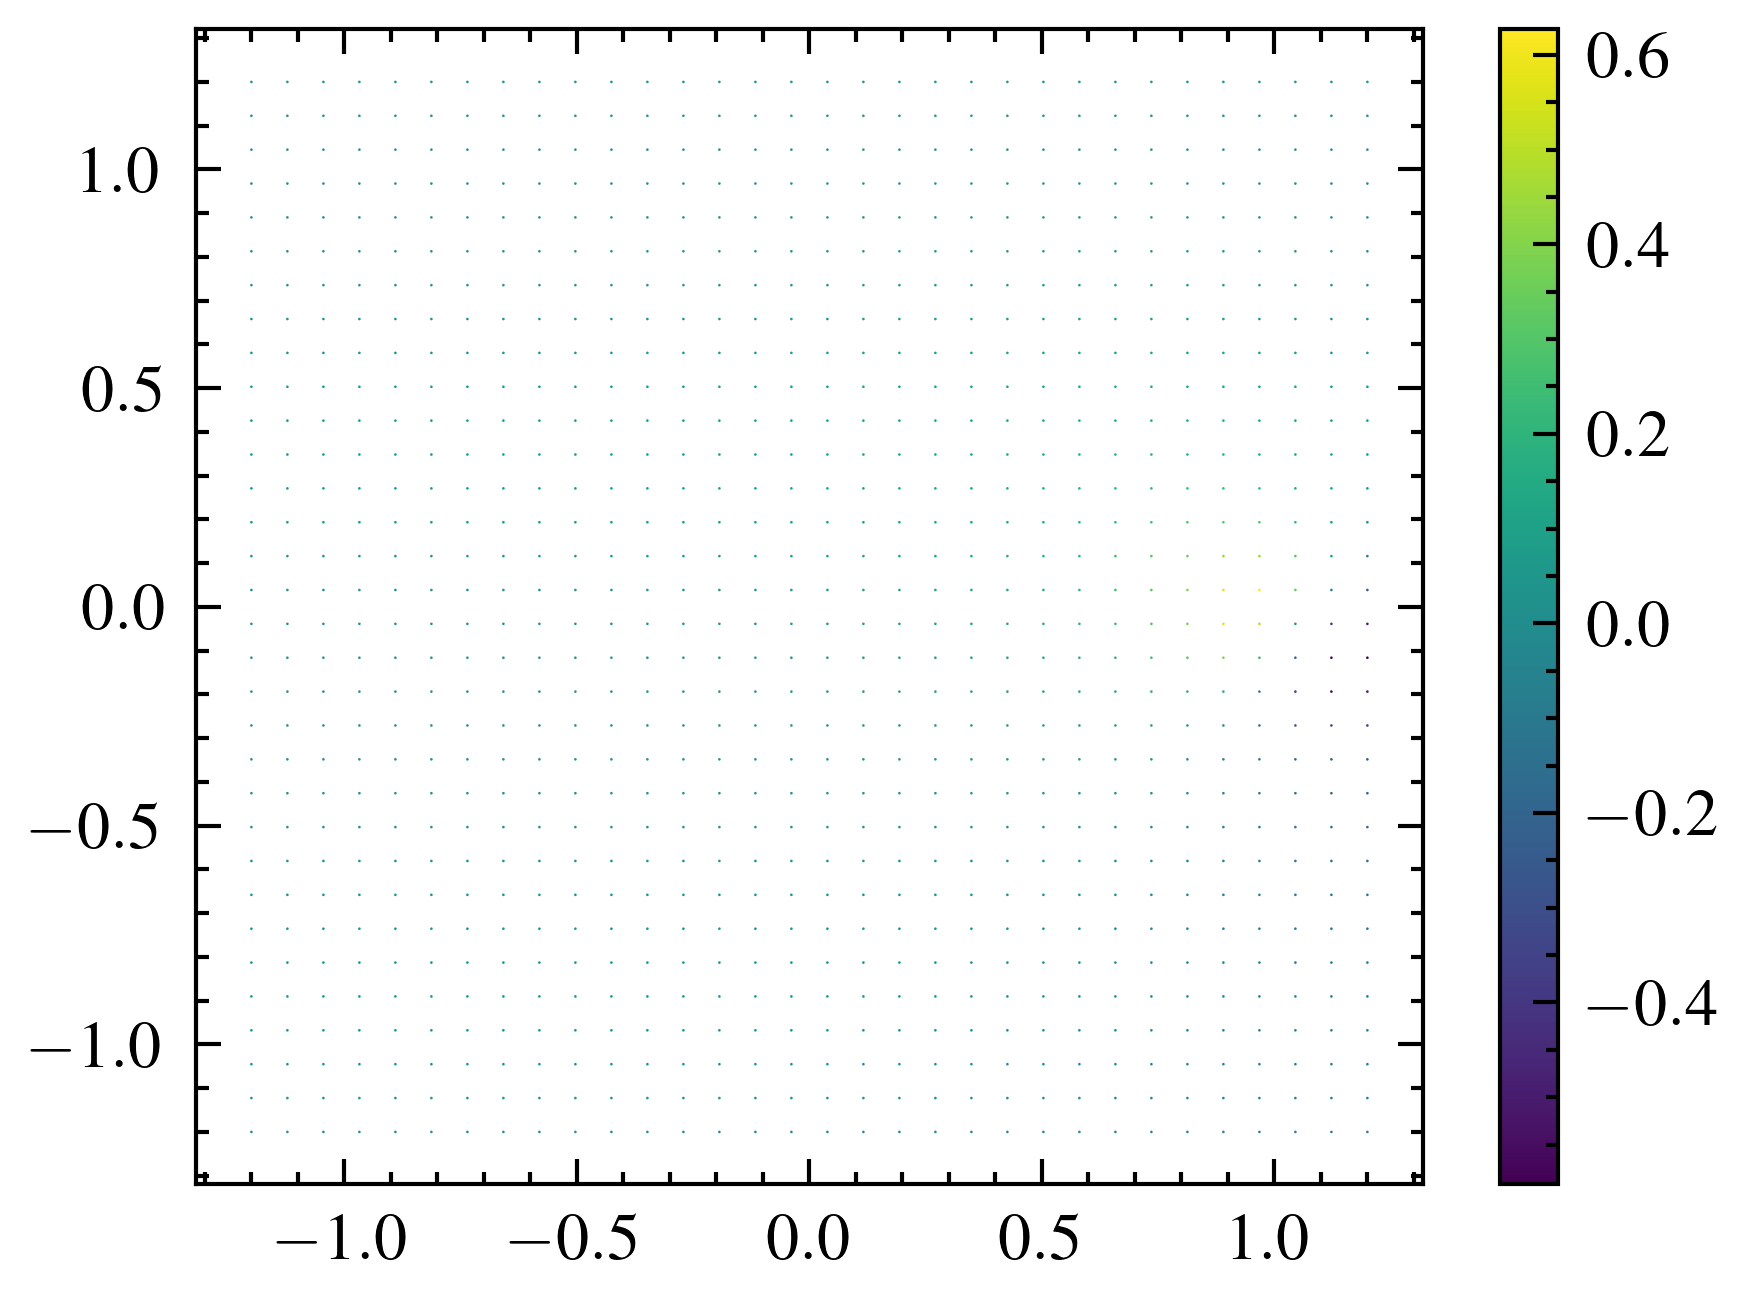

In [9]:
contour_msp = plt.scatter(x_grid, y_grid, c=db["output"][idx].reshape((res, res)), cmap='viridis', s=0.1, edgecolors='none')
plt.colorbar(contour_msp)

[0.16990328 0.1699959  0.17011733 0.1701843  0.17098518 0.17154972
 0.17178024 0.17204088 0.17206627 0.17333722 0.17338394 0.1742239
 0.174732   0.17490041 0.17537645 0.17545678 0.1756565  0.17584617
 0.17607082 0.17631988 0.17671737 0.177471   0.1782538  0.17830947
 0.18012482 0.18077627 0.18095109 0.18144055 0.18338428 0.18361741
 0.18400173 0.18522584 0.18557188 0.18620127 0.18633631 0.18683705
 0.18700312 0.18707006 0.18712689 0.18799841 0.18866989 0.18913881
 0.18961613 0.18973331 0.189893   0.19069526 0.1907856  0.19157076
 0.19173615 0.19260968]


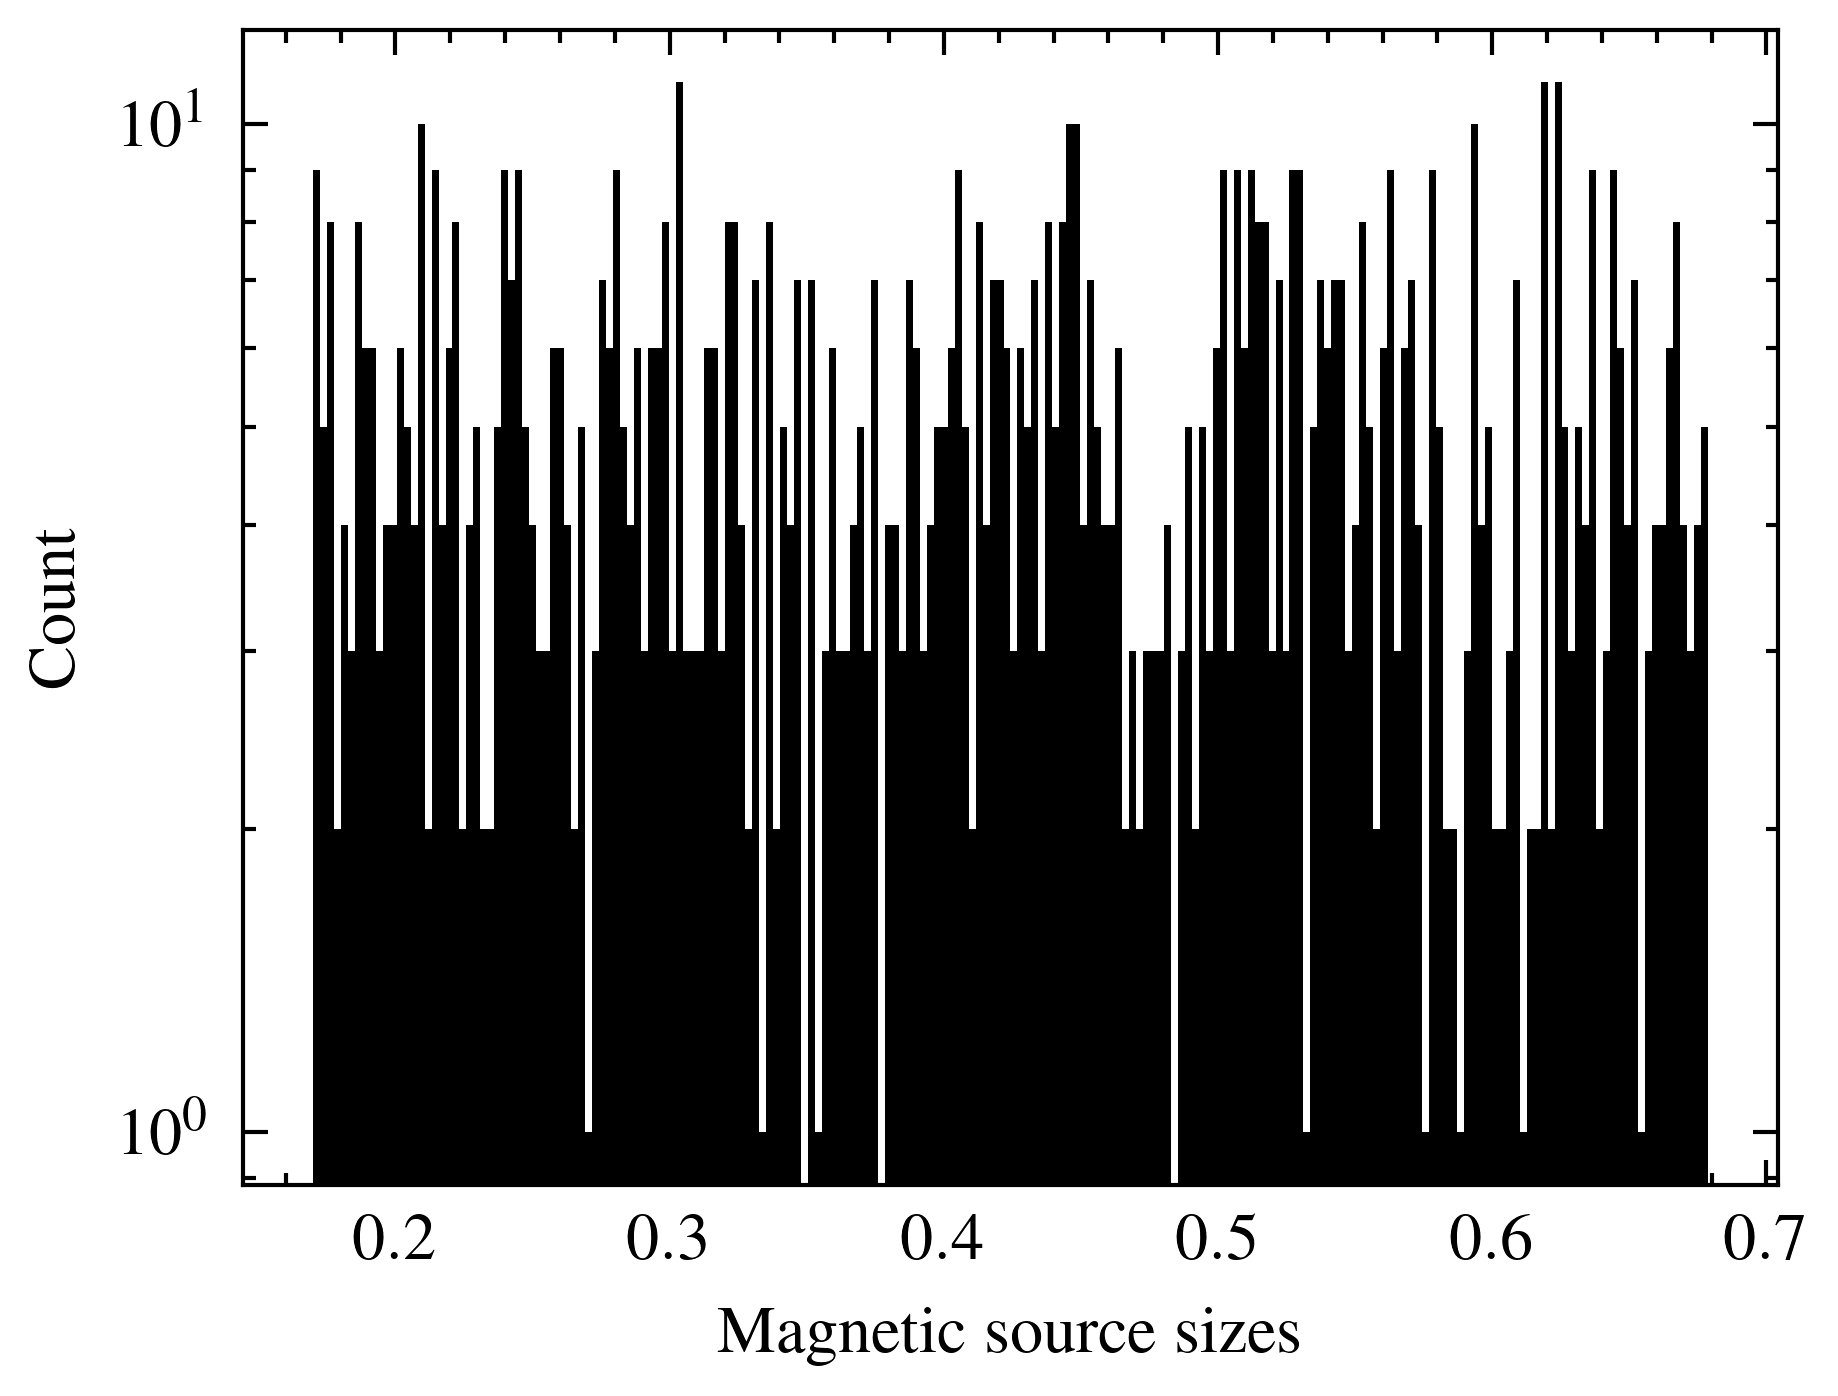

Indices with size == 0: []
Count: 0


In [3]:
# Size overview
sizes = np.linalg.norm(data["sources"][:990,0,4:6], axis=1)
print(np.sort(sizes)[:50])
plt.hist(sizes, bins=200)
plt.yscale("log")
plt.xlabel("Magnetic source sizes")
plt.ylabel("Count")
plt.show()
zero_idxs = np.where(sizes == 0)[0]
print("Indices with size == 0:", zero_idxs)
print("Count:", zero_idxs.size)
if zero_idxs.size:
    print("Example corresponding source entries:")
    print(data["sources"][zero_idxs][:3])

2.2474668 -2.5162127


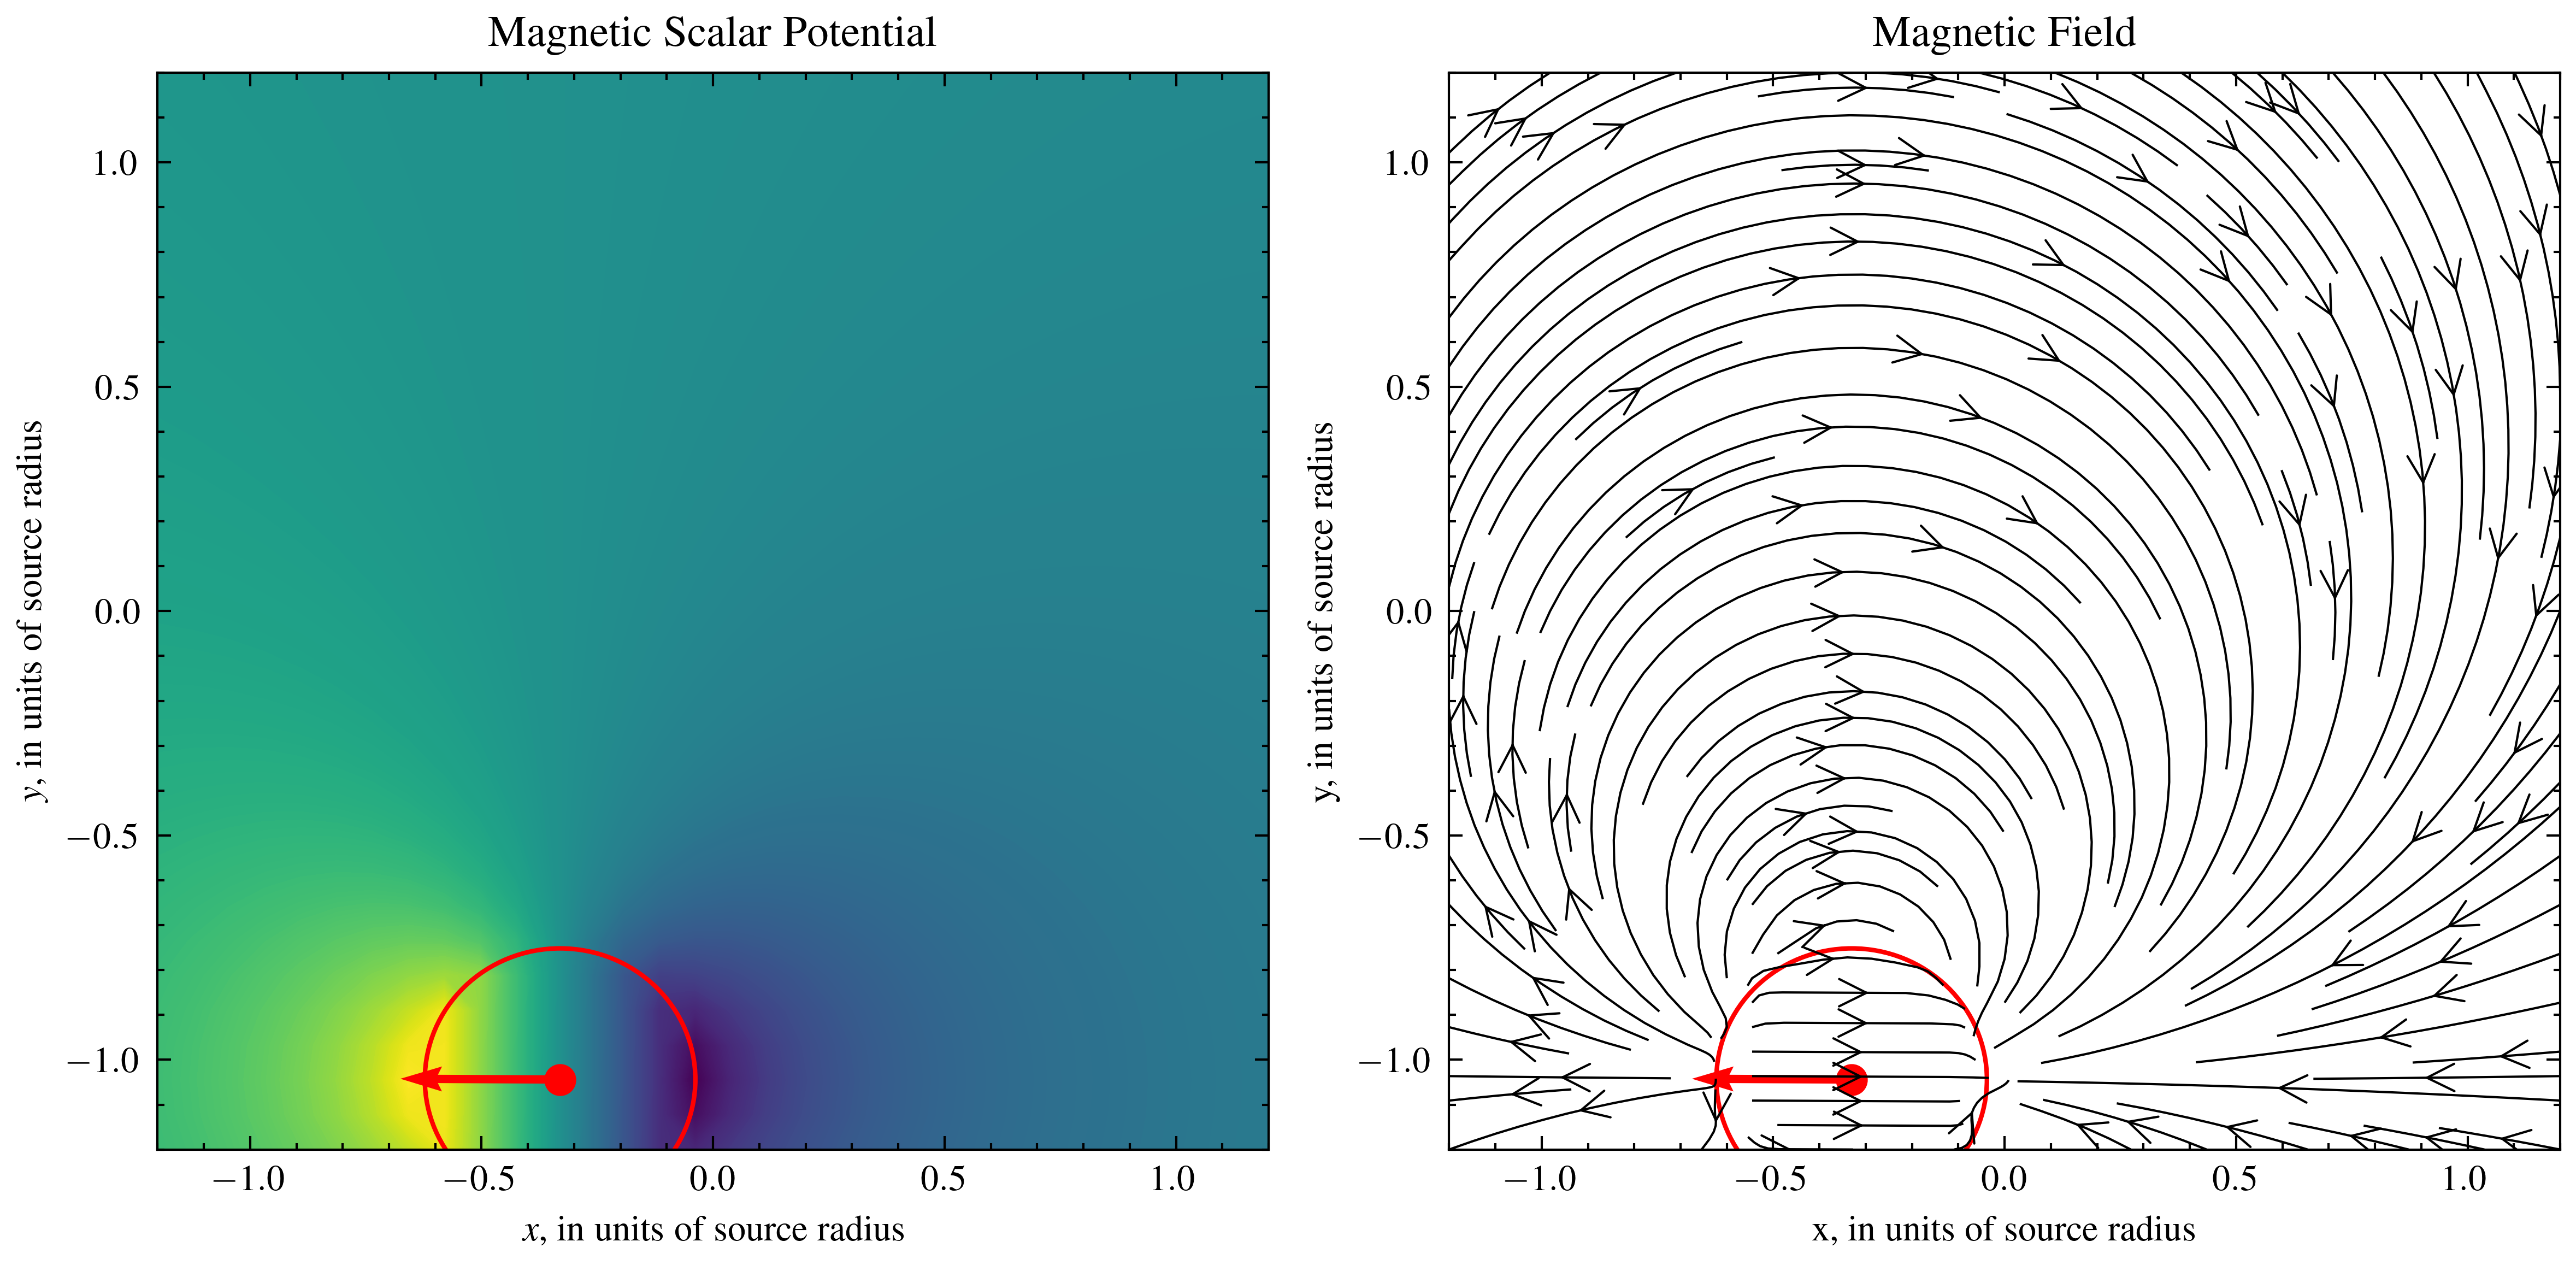

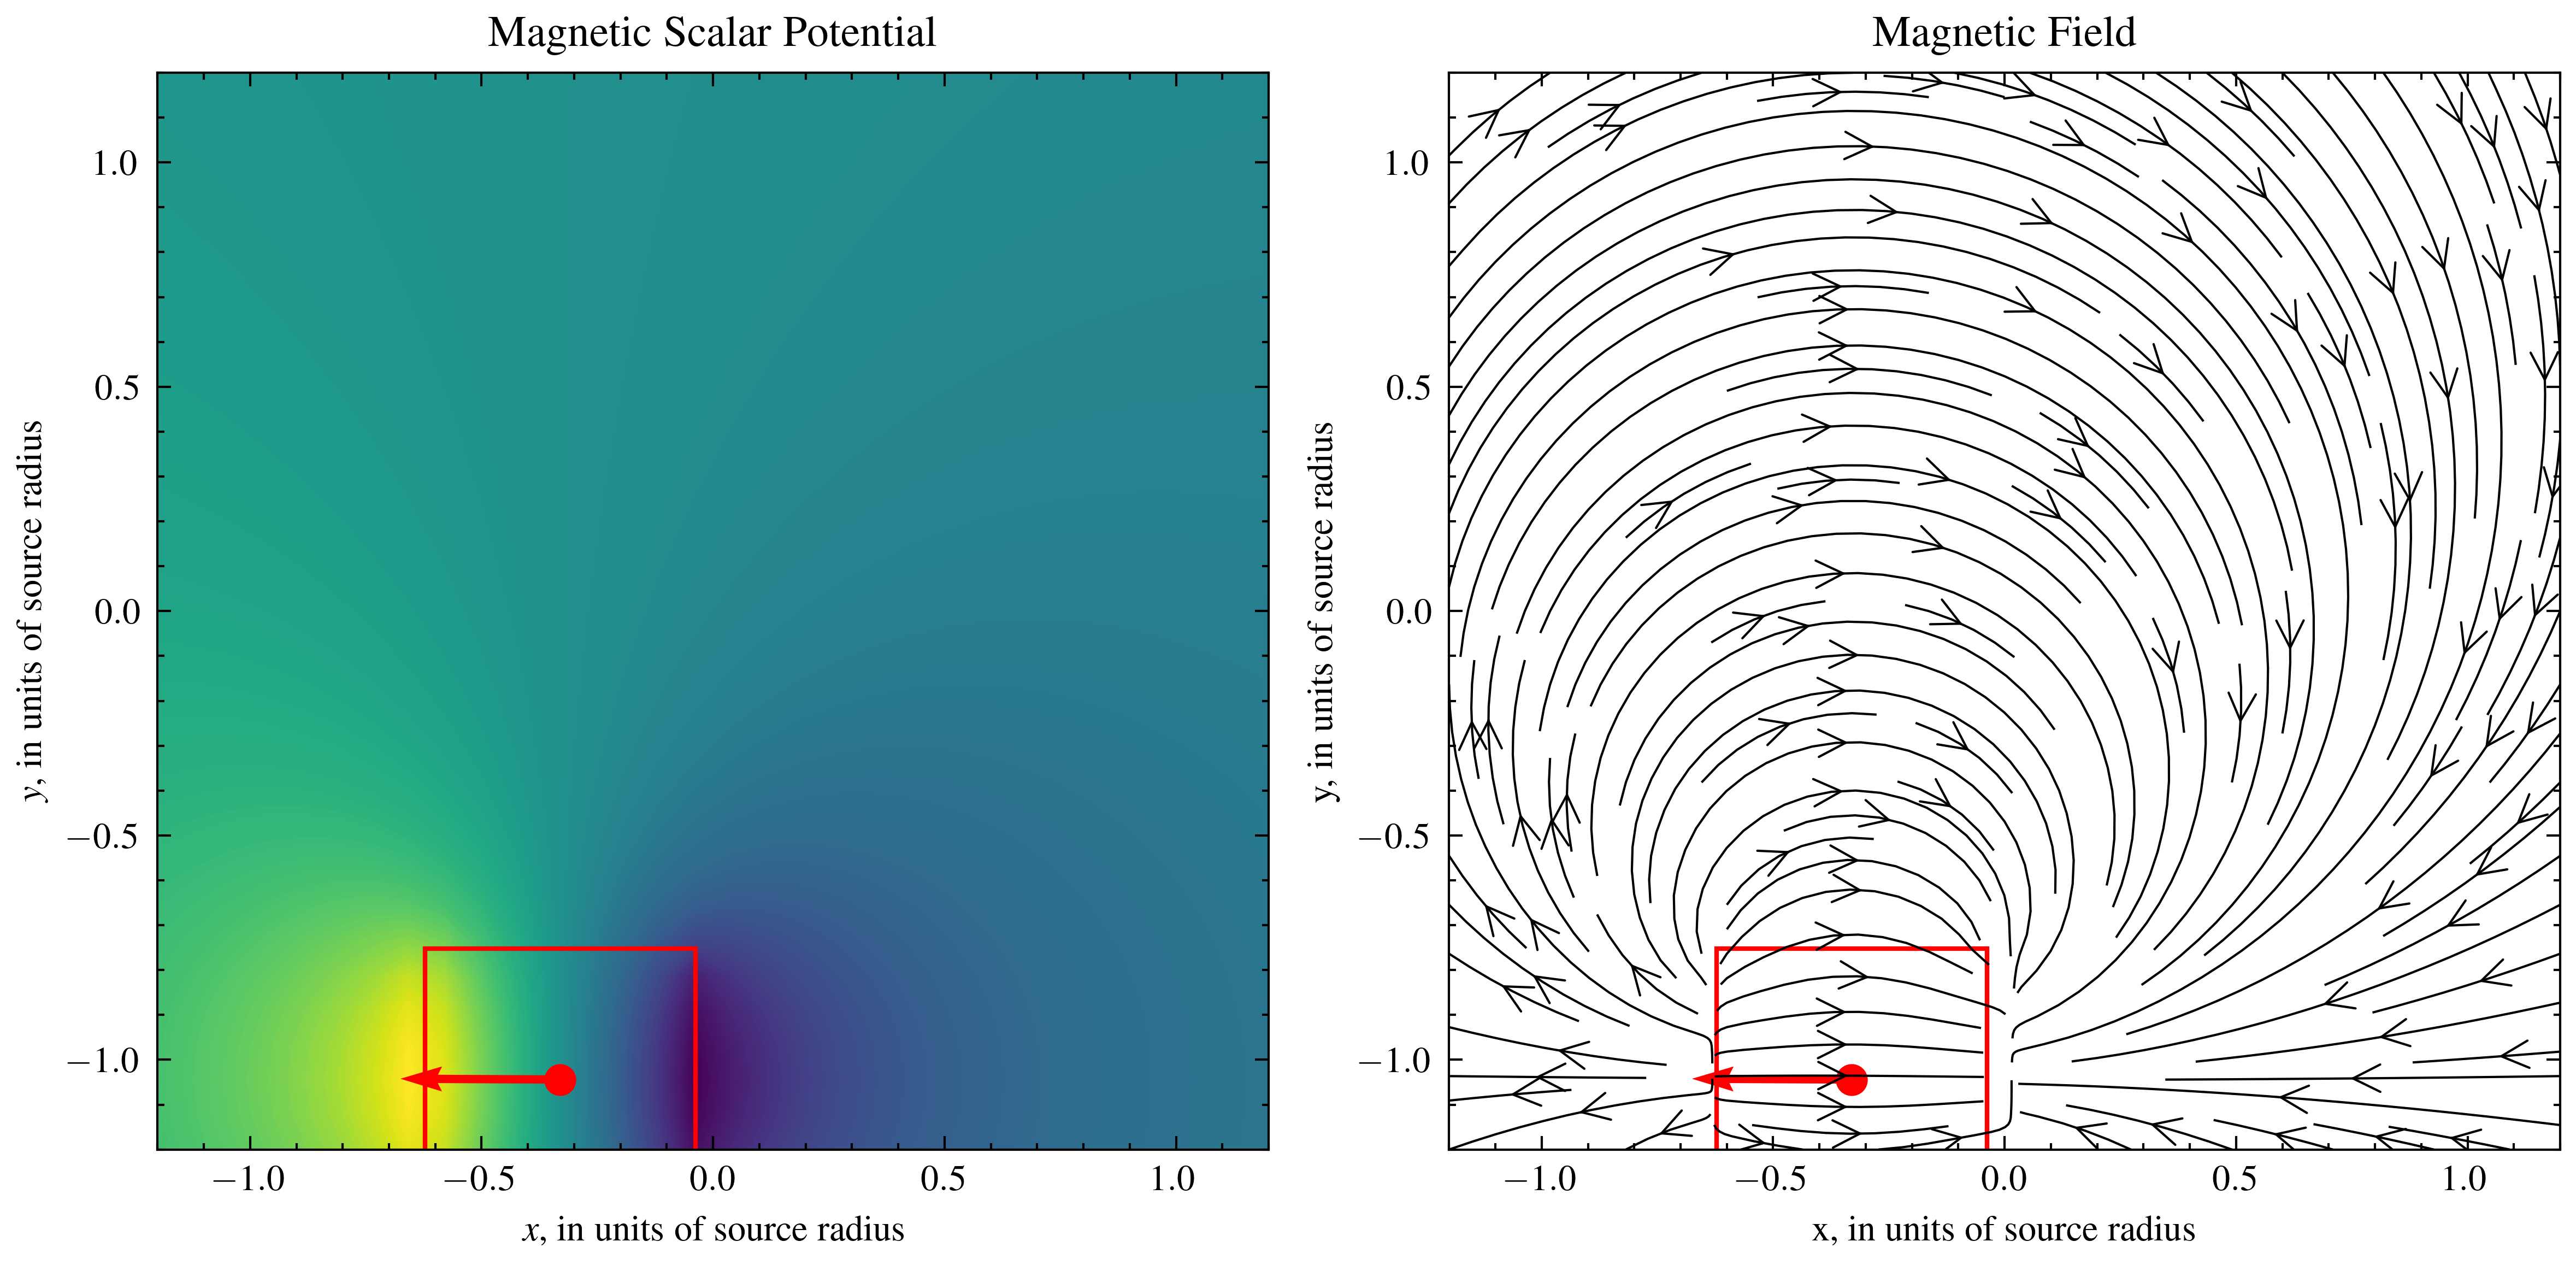

In [4]:
x_grid = np.array(data['grid'][:, 0].reshape((res, res)))
y_grid = np.array(data['grid'][:, 1].reshape((res, res)))
gt_msp = data["msp_grid"][idx].reshape((res, res))
print(gt_msp.max(), gt_msp.min())
max_abs = max(abs(gt_msp.max()), abs(gt_msp.min()))
vmax = max_abs / 10
vmin = -max_abs / 10
cbar_ticks = np.linspace(-int(max_abs)/10, int(max_abs)/10, int(max_abs)*2+1)

plots(data, loc=True, edge=True, idx=idx, output="show")
plots(data_prism, loc=True, edge=True, idx=idx, output="show")
# norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
levels = np.linspace(vmin, vmax, 250)  # evenly spaced, symmetric levels
# contour = plt.contourf(x_grid, y_grid, np.clip(gt_msp / 10, vmin, vmax), levels=levels, cmap='viridis', norm=norm)
# cbar = plt.colorbar(contour)
# cbar.set_ticks(cbar_ticks)

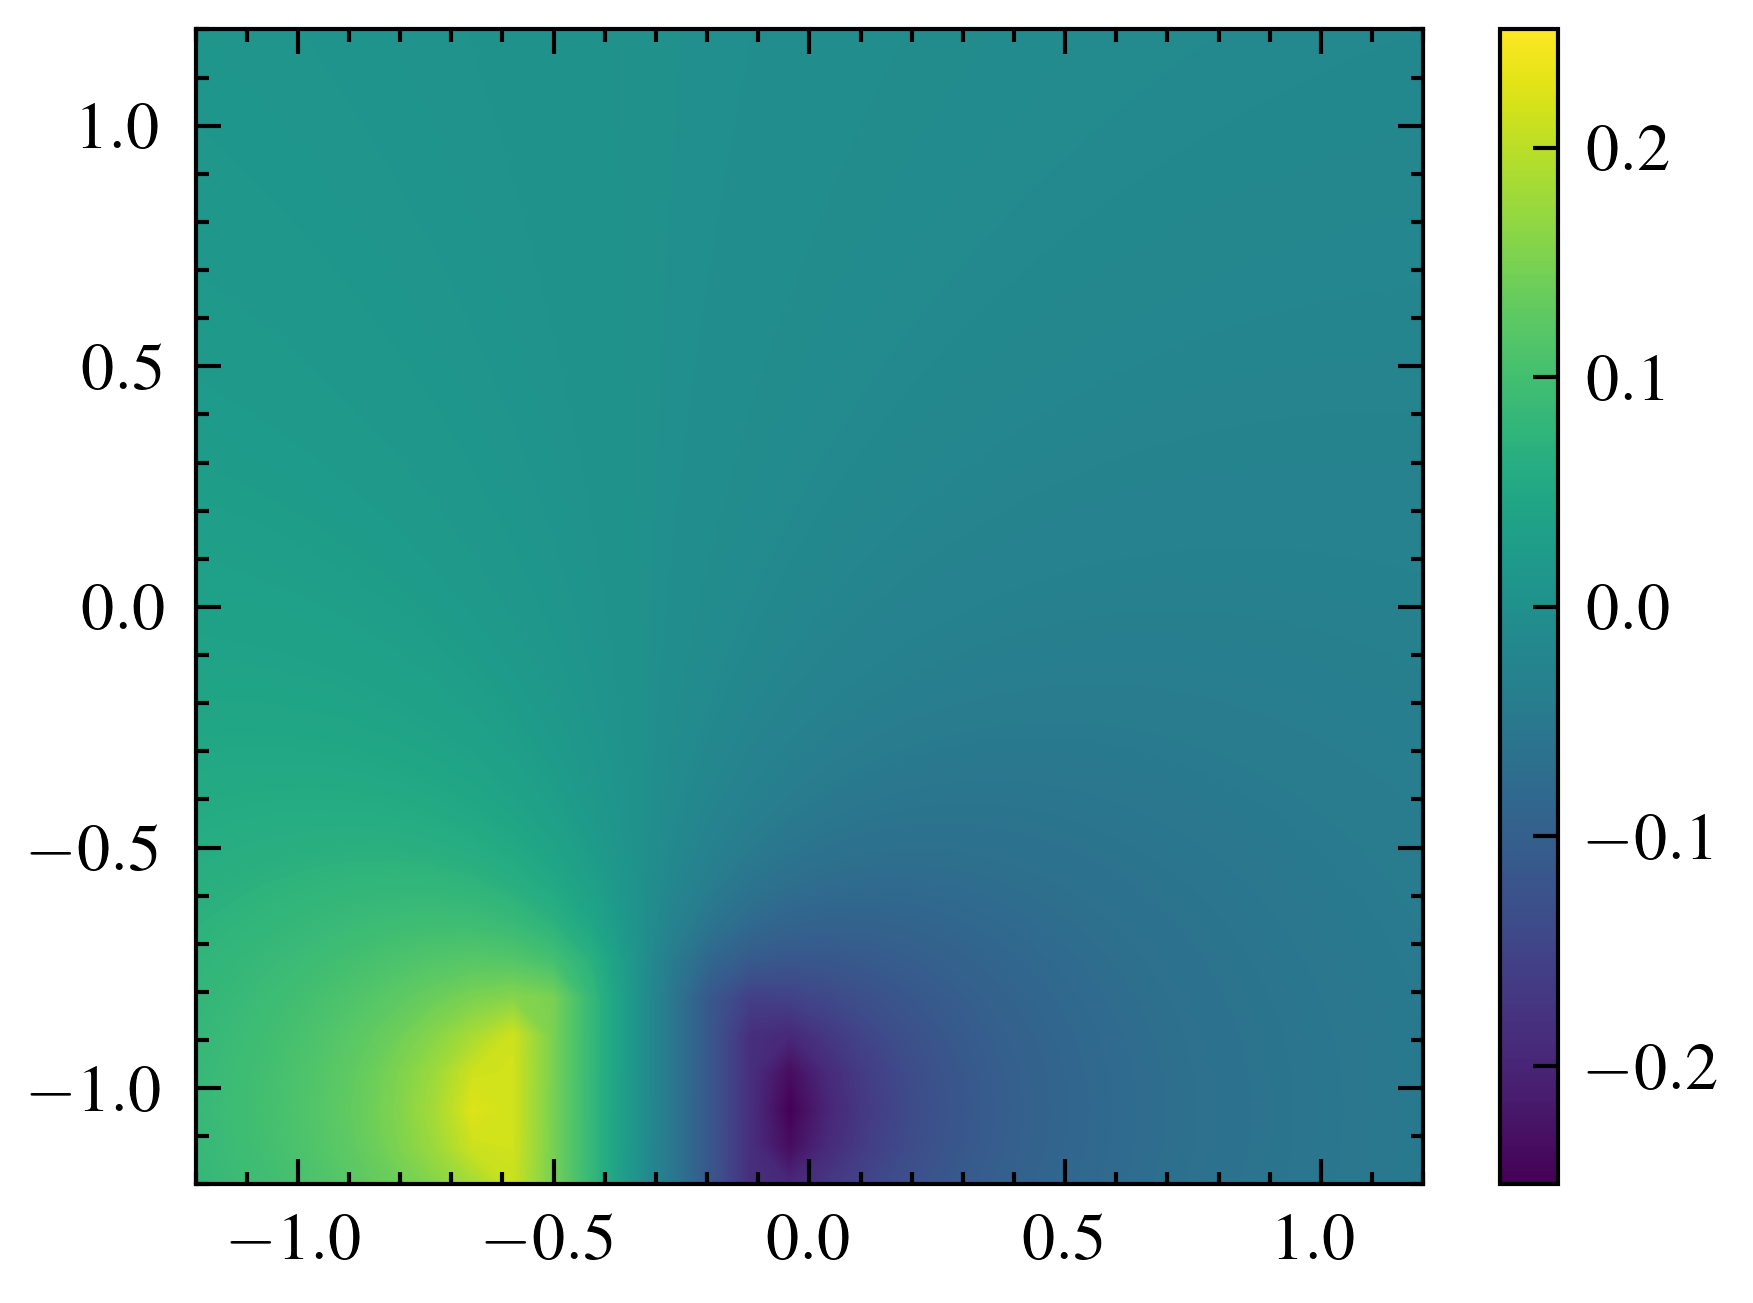

In [5]:
# Potential 2D data
sim = data.copy()
sim_fmm, _, _ = potential2D(data['sources'], sim['shape'], data["grid"], correction_source=False, prism_mt=False)
    
contour = plt.contourf(x_grid, y_grid, sim_fmm[idx].reshape((res, res))/10, levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

(990, 1024)


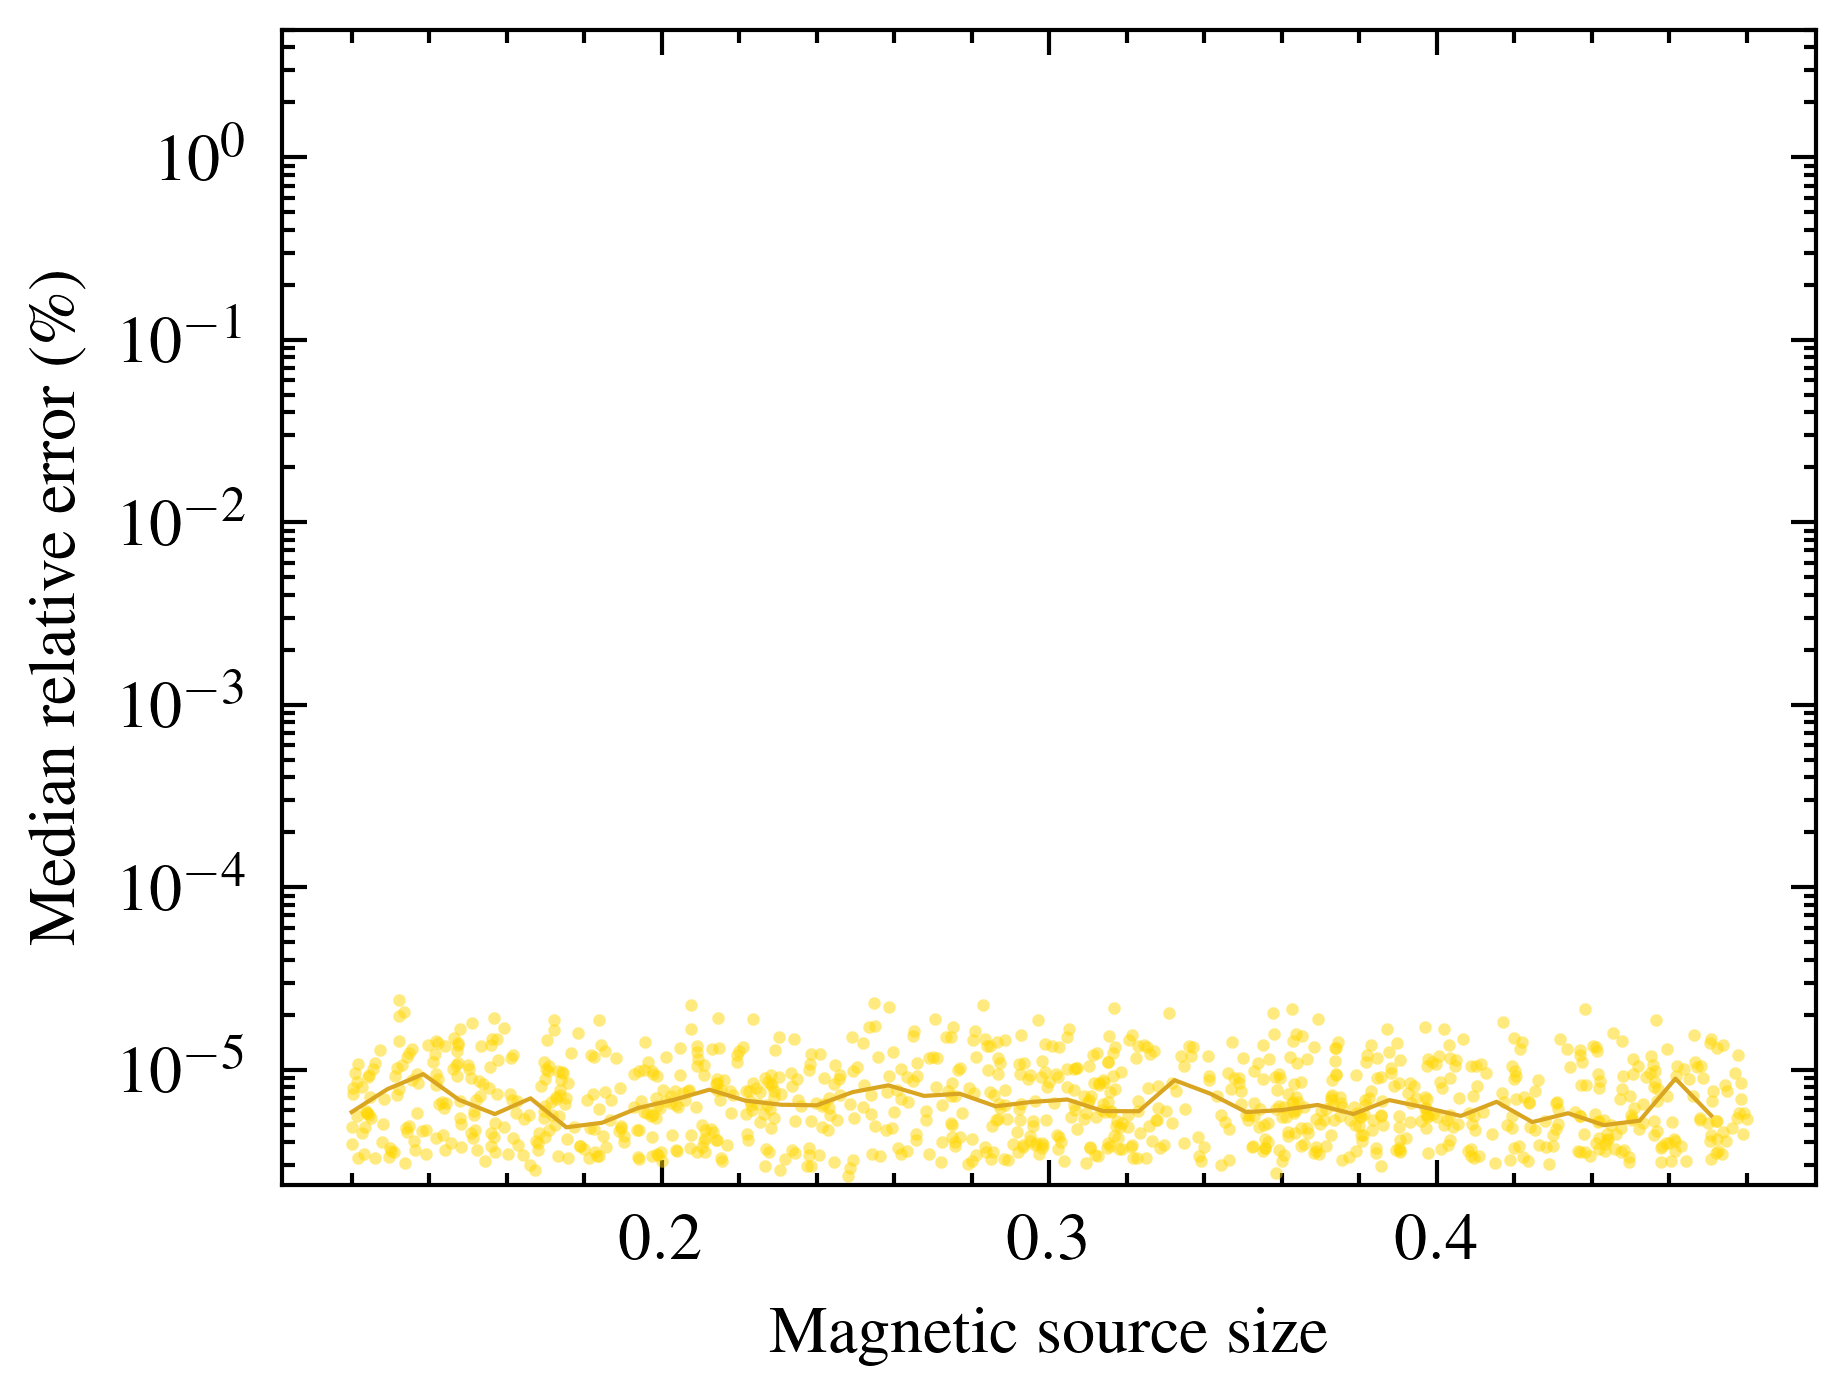

In [6]:
# Prepare FMM2D error analysis
err_fmm = (np.abs(sim_fmm[:990] - data["msp_grid"][:990]) / np.abs(data["msp_grid"][:990])) * 100
print(err_fmm.shape)
m_relerr_fmm = np.nanmedian(err_fmm, axis=-1)
abserr_fmm = np.abs(sim_fmm[:990] - data["msp_grid"][:990])
m_abserr_fmm = np.nanmean(abserr_fmm, axis=-1)

plt.plot(data["sources"][:990,0,4], m_relerr_fmm, 'o', markersize=0.5, c='gold', alpha=0.5)
plt.yscale("log")
plt.ylim(0, 5)
plt.xlabel("Magnetic source size")
plt.ylabel("Median relative error (\%)")
# plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes.png", dpi=300)

#: 0: d_size_normed, 1: err, 2: comp
d_err = np.vstack([data["sources"][:990,0,4].flatten(), m_relerr_fmm.flatten()]).T

d_bins = np.linspace(0.12, 0.48, 40)
bin_indices = np.digitize(d_err[:,0], d_bins)

bin_medians = []
for i in range(1, len(d_bins)):
    bin_data = d_err[bin_indices == i]
    if bin_data.size > 0:
        bin_medians.append(np.nanmedian(bin_data[:,1]))
    else:
        bin_medians.append(np.nan)
plt.plot(d_bins[:-1], bin_medians, '-', color='goldenrod', linewidth=0.5)
plt.savefig("/home/spol/repos/hypermagnetics/figs/fmm_relerr_sizes.svg")

In [7]:
# Prepare prism vs shape error
err_prism = (np.abs(data["msp_grid"][:990] * (4/np.pi) - data_prism["msp_grid"][:990]) / np.abs(data_prism["msp_grid"][:990])) * 100
print(err_prism.shape)
m_relerr_prism = np.nanmedian(err_prism, axis=-1)
abserr_prism = np.abs(data_prism["msp_grid"][:990] - data["msp_grid"][:990])
m_abserr_prism = np.nanmean(abserr_prism, axis=-1)

(990, 1024)


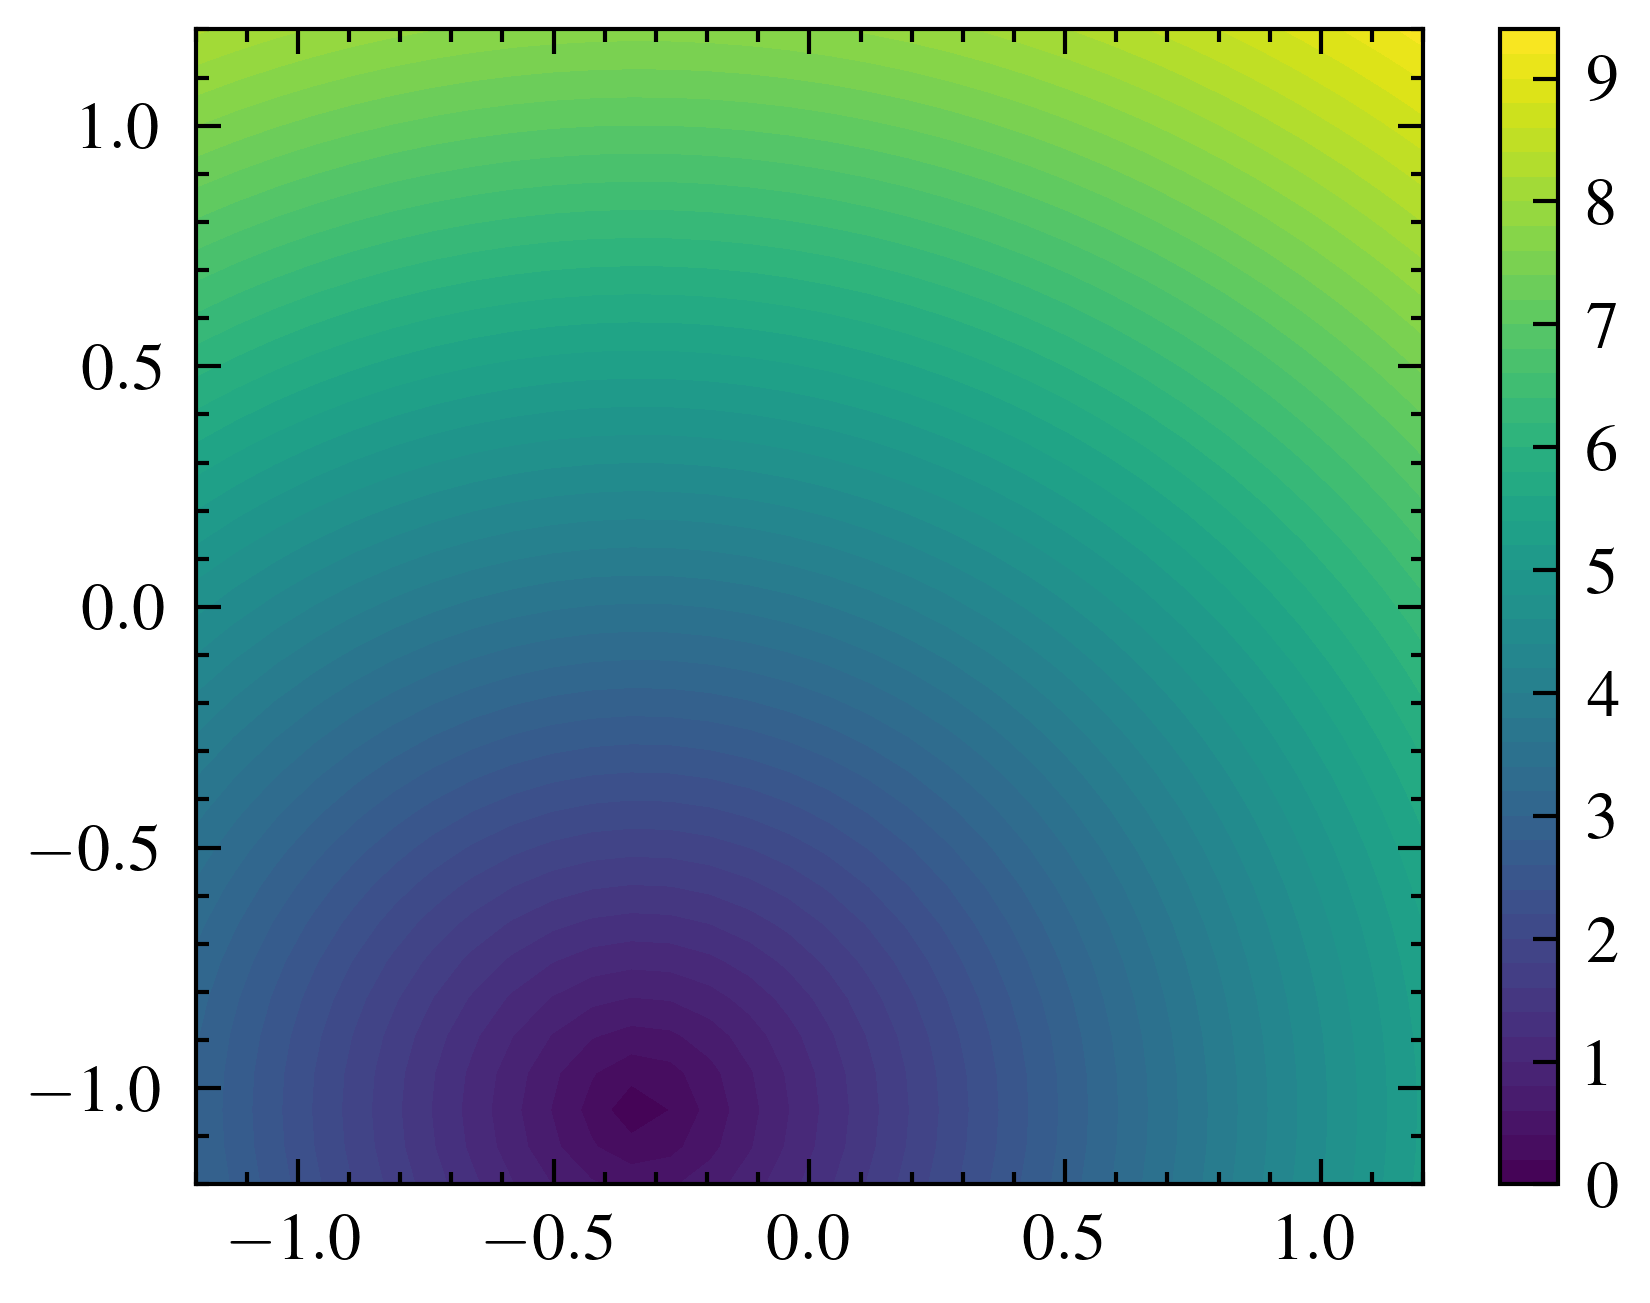

In [8]:
distances = np.linalg.norm((np.repeat(data["grid"][None, :, :], 990, axis=0) - data["sources"][:990,0,2:4][:, None, :]), axis=-1)
d_size = distances / data["sources"][:990,0,4][:, None]
plt.contourf(x_grid, y_grid, d_size[idx].reshape((res, res)), levels=50)
plt.colorbar()

Text(0, 0.5, 'Absolute error (A)')

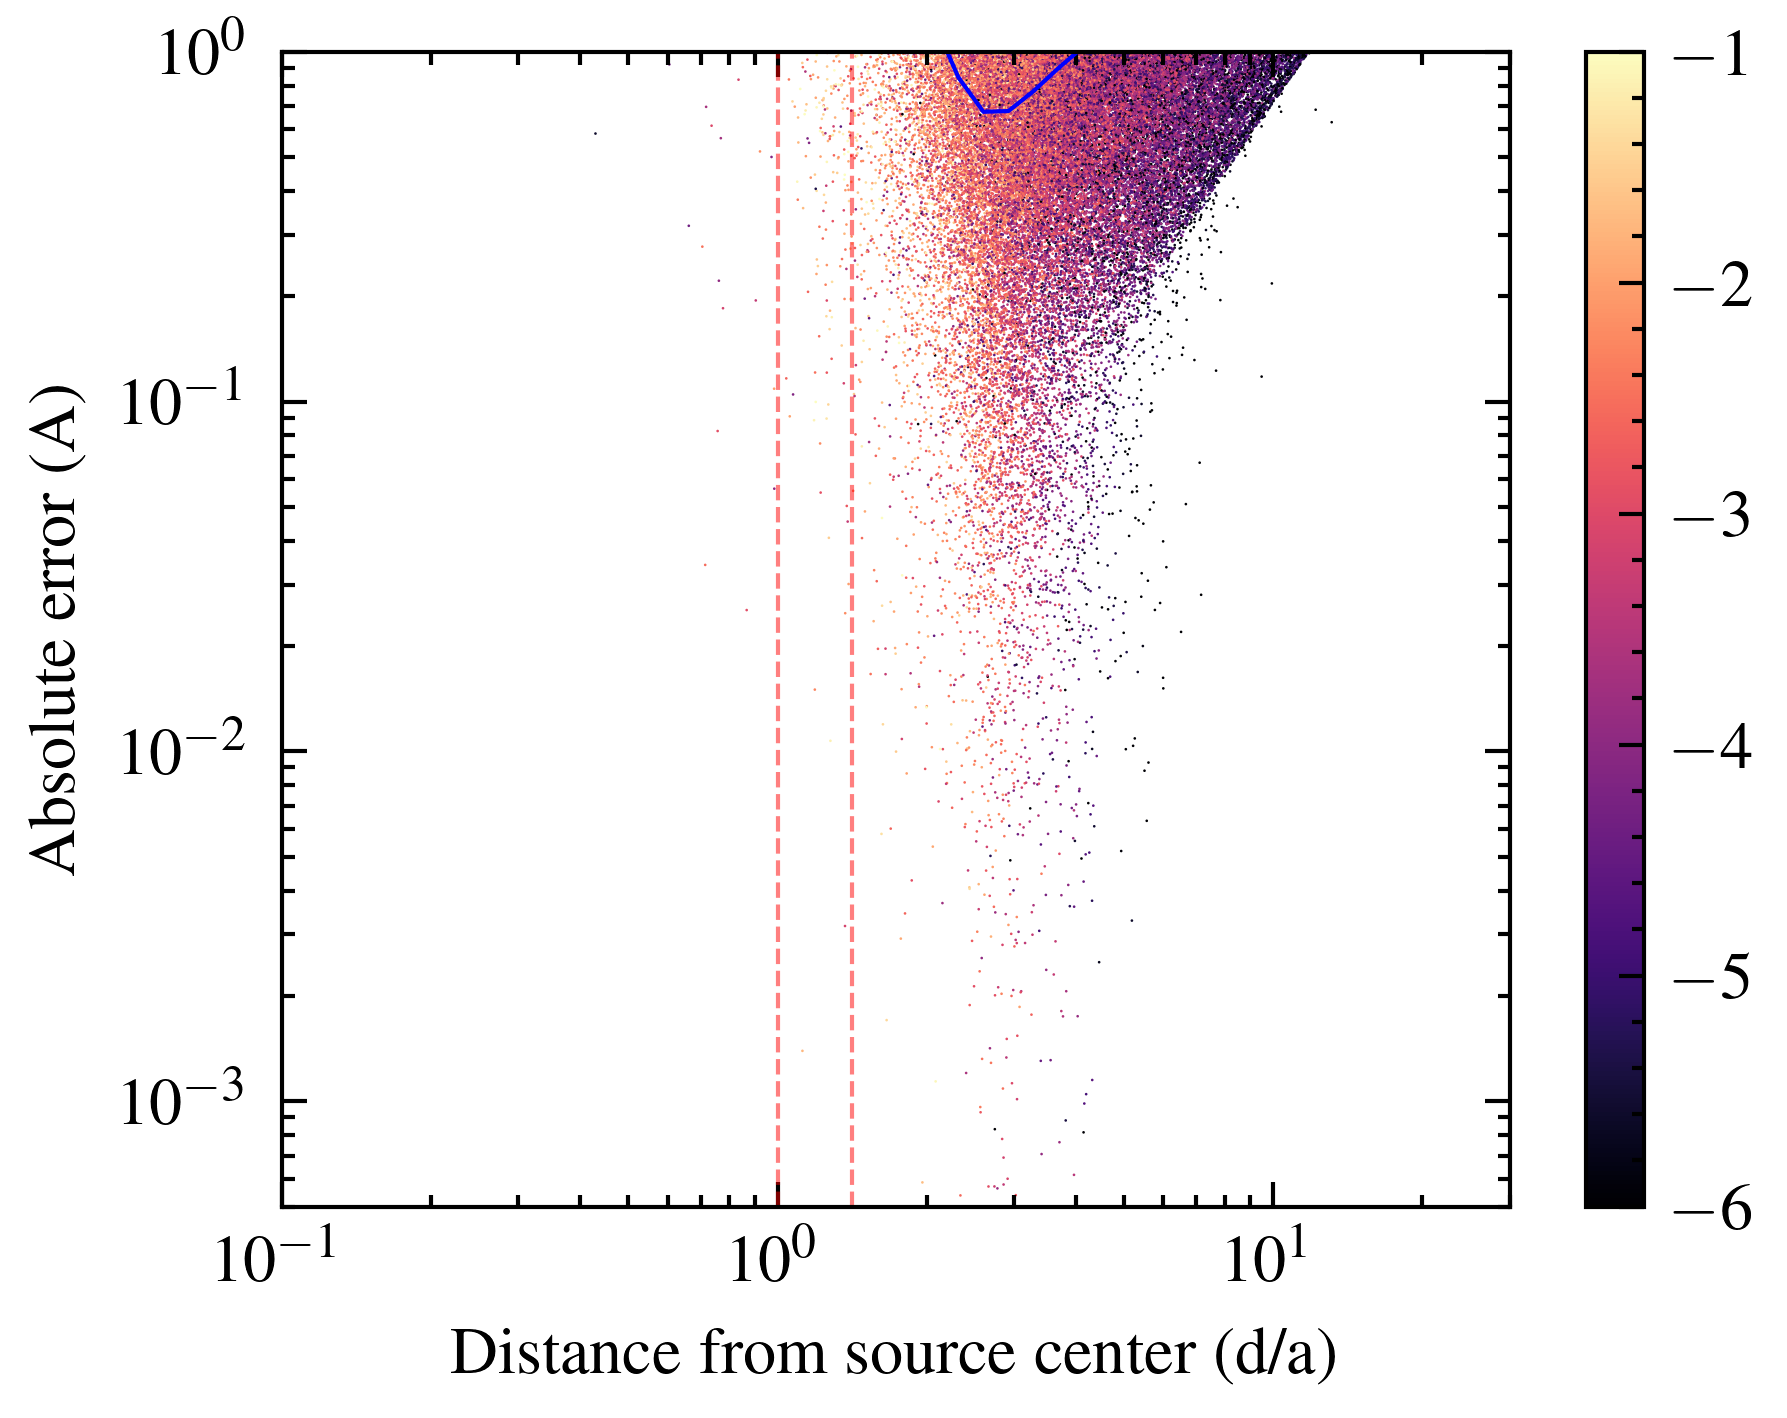

In [ ]:
# a = data["sources"][:990,0,6:7]
# m = data["sources"][:990,0,0:3]
# r0 = data["sources"][:990,0,3:6]
comp = abs(data_prism["msp_grid"][:990]) / 10
# comp_var = a
# comp = np.repeat(np.linalg.norm(comp_var, axis=-1)[:, None], res**2, axis=-1)
plt.scatter(d_size.flatten()[::10], abserr_prism.flatten()[::10], s=0.1, edgecolors='none', c=np.clip(np.log(comp.flatten()[::10]), -6, -1), cmap="magma", alpha=1) # c='plum', alpha=0.1)
# plt.scatter(d_size.flatten(), err_fmm.flatten(), s=0.1, edgecolors='none', c='gold', alpha=0.1) # c=comp.flatten(), cmap="magma")
plt.colorbar()

#: 0: d_size_normed, 1: err, 2: comp
# d_err = np.vstack([d_size.flatten(), err_fcilr.flatten(), comp.flatten()]).T
d_err_fmm = np.vstack([d_size.flatten(), abserr_prism.flatten(), comp.flatten()]).T

d_bins = np.linspace(np.log(1e-1), np.log(30), 50)
# bin_indices = np.digitize(d_err[:,0], np.exp(d_bins))
bin_indices_fmm = np.digitize(d_err_fmm[:,0], np.exp(d_bins))

bin_medians = []
bin_medians_fmm = []
bin_smallest = []
bin_largest = []
for i in range(1, len(d_bins)):
    # bin_data = d_err[bin_indices == i]
    bin_data_fmm = d_err_fmm[bin_indices_fmm == i]
    if bin_data_fmm.size > 0:
        # bin_medians.append(np.nanmedian(bin_data[:,1]))
        bin_medians_fmm.append(np.nanmedian(bin_data_fmm[:,1]))
        bin_smallest.append(np.nanmedian(bin_data_fmm[:,1][bin_data_fmm[:,2] <= 1e-3]))
        bin_largest.append(np.nanmedian(bin_data_fmm[:,1][bin_data_fmm[:,2] >= 1e-1]))
    else:
        # bin_medians.append(np.nan)
        bin_medians_fmm.append(np.nan)
        bin_smallest.append(np.nan)
        bin_largest.append(np.nan)
# plt.plot(np.exp(d_bins[:-1]), bin_medians, '-', color='purple', linewidth=0.75)
plt.plot(np.exp(d_bins[:-1]), bin_medians_fmm, '-', color='blue', linewidth=0.5)
plt.axvline(1, color='red', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axvline(np.sqrt(2), color='red', linestyle='--', linewidth=0.5, alpha=0.5)
# plt.plot(np.exp(d_bins[:-1]), bin_smallest, '--', color='black', linewidth=0.75)
# plt.plot(np.exp(d_bins[:-1]), bin_largest, '--', color='goldenrod', linewidth=0.75)
plt.yscale("log")
plt.ylim(5e-4, 1)
plt.xscale("log")
plt.xlim(1e-1, 30)
plt.xlabel("Distance from source center (d/a)")
plt.ylabel("Absolute error (A)")
# plt.savefig("/home/spol/repos/hypermagnetics/figs/fcilr_relerr_sizes_small_large_scatter.svg")
